# Test 7: Statistical Significance

Determine if any mRMSE differences between quantum ON and OFF are statistically significant.
Uses bootstrap CI, paired t-test, and Cohen's d.

**Key question:** Is the measured quantum advantage (if any) statistically robust?

In [1]:
from setup_helpers import *
from scipy import stats

ckpt = load_checkpoint()
model, model_cfg, device = build_trained_model(ckpt)
data = load_data()
print("Model and data loaded.")

Model and data loaded.


In [2]:
# Get per-sample predictions for both conditions on holdout
m_on = evaluate(model, data.holdout, data.target_scaler, enable_quantum=True, quantum_scale=QUANTUM_SCALE_AT_BEST)
m_off = evaluate(model, data.holdout, data.target_scaler, enable_quantum=False)

pred_on = m_on["pred_orig"]   # (N, 5)
pred_off = m_off["pred_orig"] # (N, 5)
true = m_on["true_orig"]      # (N, 5)

# Per-sample squared errors
se_on = (pred_on - true) ** 2   # (N, 5)
se_off = (pred_off - true) ** 2 # (N, 5)

N = true.shape[0]
print(f"Holdout samples: {N}")
print(f"mRMSE ON:  {m_on['rmse_mean']:.4f}")
print(f"mRMSE OFF: {m_off['rmse_mean']:.4f}")
print(f"Delta:     {m_on['rmse_mean'] - m_off['rmse_mean']:+.4f}")

Holdout samples: 4143
mRMSE ON:  0.2956
mRMSE OFF: 0.3024
Delta:     -0.0069


## 7.1 — Paired t-test per target

In [3]:
# Paired t-test: is mean squared error different between ON and OFF?
ttest_rows = []
for i, name in enumerate(TARGET_NAMES):
    t_stat, p_value = stats.ttest_rel(se_on[:, i], se_off[:, i])
    mean_diff = se_on[:, i].mean() - se_off[:, i].mean()
    sig = "Yes" if p_value < 0.05 else "No"
    direction = "quantum helps" if mean_diff < 0 else "quantum hurts"
    ttest_rows.append({
        "Target": name,
        "Mean SE diff (ON-OFF)": f"{mean_diff:+.6f}",
        "t-statistic": f"{t_stat:.4f}",
        "p-value": f"{p_value:.6f}",
        "Significant (p<0.05)": sig,
        "Direction": direction,
    })

# Overall mRMSE t-test
# Per-sample mean RMSE across targets
sample_rmse_on = np.sqrt(se_on.mean(axis=1))  # (N,)
sample_rmse_off = np.sqrt(se_off.mean(axis=1)) # (N,)
t_stat_overall, p_overall = stats.ttest_rel(sample_rmse_on, sample_rmse_off)
ttest_rows.append({
    "Target": "OVERALL (mean RMSE)",
    "Mean SE diff (ON-OFF)": f"{sample_rmse_on.mean() - sample_rmse_off.mean():+.6f}",
    "t-statistic": f"{t_stat_overall:.4f}",
    "p-value": f"{p_overall:.6f}",
    "Significant (p<0.05)": "Yes" if p_overall < 0.05 else "No",
    "Direction": "quantum helps" if sample_rmse_on.mean() < sample_rmse_off.mean() else "quantum hurts",
})

display(pd.DataFrame(ttest_rows).set_index("Target"))

,Mean SE diff (ON-OFF),t-statistic,p-value,Significant (p<0.05),Direction
Target,,,,,
H₂O,-0.009614,-4.9766,0.000001,Yes,quantum helps
CO₂,-0.004946,-7.0716,0.000000,Yes,quantum helps
CO,-0.001264,-6.2637,0.000000,Yes,quantum helps
CH₄,-0.000398,-1.3082,0.190864,No,quantum helps
NH₃,-0.006469,-5.7122,0.000000,Yes,quantum helps
OVERALL (mean RMSE),-0.007130,-11.6440,0.000000,Yes,quantum helps


## 7.2 — Bootstrap confidence interval for mRMSE difference

In [4]:
N_BOOTSTRAP = 10000
rng = np.random.RandomState(42)

bootstrap_deltas = []
for _ in range(N_BOOTSTRAP):
    idx = rng.randint(0, N, size=N)
    mrmse_on = np.sqrt(np.mean((pred_on[idx] - true[idx]) ** 2, axis=0)).mean()
    mrmse_off = np.sqrt(np.mean((pred_off[idx] - true[idx]) ** 2, axis=0)).mean()
    bootstrap_deltas.append(mrmse_on - mrmse_off)

bootstrap_deltas = np.array(bootstrap_deltas)
ci_lower = np.percentile(bootstrap_deltas, 2.5)
ci_upper = np.percentile(bootstrap_deltas, 97.5)
observed_delta = m_on["rmse_mean"] - m_off["rmse_mean"]

print(f"Observed mRMSE delta (ON - OFF): {observed_delta:+.4f}")
print(f"95% Bootstrap CI: [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"CI includes zero: {'YES' if ci_lower <= 0 <= ci_upper else 'NO'}")

if ci_upper < 0:
    print("VERDICT: Quantum ON significantly BETTER (CI fully below 0)")
elif ci_lower > 0:
    print("VERDICT: Quantum ON significantly WORSE (CI fully above 0)")
else:
    print("VERDICT: Difference NOT significant (CI includes 0)")

Observed mRMSE delta (ON - OFF): -0.0069
95% Bootstrap CI: [-0.0081, -0.0056]
CI includes zero: NO
VERDICT: Quantum ON significantly BETTER (CI fully below 0)


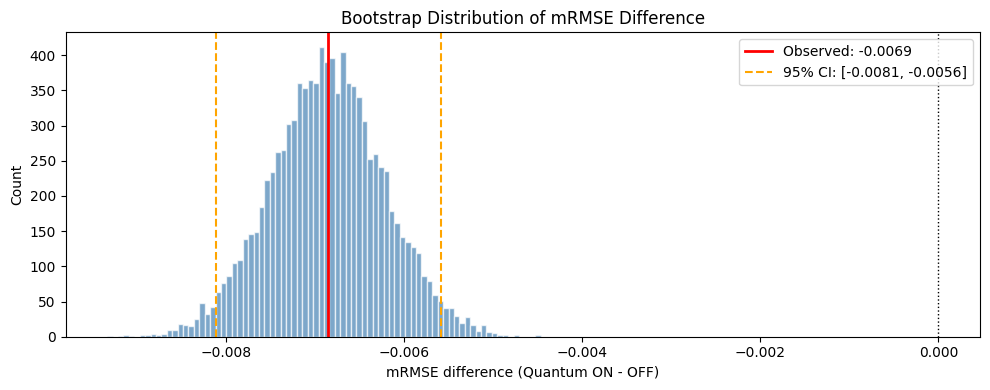

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(bootstrap_deltas, bins=80, alpha=0.7, color="steelblue", edgecolor="white")
ax.axvline(observed_delta, color="red", linewidth=2, label=f"Observed: {observed_delta:+.4f}")
ax.axvline(ci_lower, color="orange", linestyle="--", label=f"95% CI: [{ci_lower:+.4f}, {ci_upper:+.4f}]")
ax.axvline(ci_upper, color="orange", linestyle="--")
ax.axvline(0, color="black", linewidth=1, linestyle=":")
ax.set_xlabel("mRMSE difference (Quantum ON - OFF)")
ax.set_ylabel("Count")
ax.set_title("Bootstrap Distribution of mRMSE Difference")
ax.legend()
plt.tight_layout()
plt.show()

## 7.3 — Effect size (Cohen's d)

In [6]:
# Cohen's d per target
cohens_rows = []
for i, name in enumerate(TARGET_NAMES):
    diff = se_on[:, i] - se_off[:, i]
    d = diff.mean() / diff.std()
    magnitude = "negligible" if abs(d) < 0.2 else ("small" if abs(d) < 0.5 else ("medium" if abs(d) < 0.8 else "large"))
    cohens_rows.append({"Target": name, "Cohen's d": f"{d:+.4f}", "Magnitude": magnitude})

# Overall
diff_overall = sample_rmse_on - sample_rmse_off
d_overall = diff_overall.mean() / diff_overall.std()
mag_overall = "negligible" if abs(d_overall) < 0.2 else ("small" if abs(d_overall) < 0.5 else ("medium" if abs(d_overall) < 0.8 else "large"))
cohens_rows.append({"Target": "OVERALL", "Cohen's d": f"{d_overall:+.4f}", "Magnitude": mag_overall})

display(pd.DataFrame(cohens_rows).set_index("Target"))

,Cohen's d,Magnitude
Target,,
H₂O,-0.0773,negligible
CO₂,-0.1099,negligible
CO,-0.0973,negligible
CH₄,-0.0203,negligible
NH₃,-0.0888,negligible
OVERALL,-0.1809,negligible


## 7.4 — Per-target bootstrap CI

In [7]:
# Per-target bootstrap
per_target_ci = []
for i, name in enumerate(TARGET_NAMES):
    deltas = []
    for _ in range(N_BOOTSTRAP):
        idx = rng.randint(0, N, size=N)
        rmse_on = np.sqrt(np.mean((pred_on[idx, i] - true[idx, i]) ** 2))
        rmse_off = np.sqrt(np.mean((pred_off[idx, i] - true[idx, i]) ** 2))
        deltas.append(rmse_on - rmse_off)
    deltas = np.array(deltas)
    ci_l, ci_u = np.percentile(deltas, [2.5, 97.5])
    obs = m_on["rmse_orig"][i] - m_off["rmse_orig"][i]
    includes_zero = ci_l <= 0 <= ci_u
    per_target_ci.append({
        "Target": name,
        "Observed delta": f"{obs:+.4f}",
        "95% CI": f"[{ci_l:+.4f}, {ci_u:+.4f}]",
        "Includes zero": "Yes" if includes_zero else "No",
        "Verdict": "Not significant" if includes_zero else ("Quantum helps" if obs < 0 else "Quantum hurts"),
    })

display(pd.DataFrame(per_target_ci).set_index("Target"))

,Observed delta,95% CI,Includes zero,Verdict
Target,,,,
H₂O,-0.0121,"[-0.0168, -0.0073]",No,Quantum helps
CO₂,-0.0104,"[-0.0130, -0.0078]",No,Quantum helps
CO,-0.0027,"[-0.0036, -0.0019]",No,Quantum helps
CH₄,-0.0008,"[-0.0021, +0.0004]",Yes,Not significant
NH₃,-0.0082,"[-0.0111, -0.0054]",No,Quantum helps


In [8]:
# Summary
print("=== Statistical Significance Summary ===")
print(f"Overall mRMSE delta: {observed_delta:+.4f}")
print(f"95% Bootstrap CI: [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"Overall Cohen's d: {d_overall:+.4f} ({mag_overall})")
print(f"Overall paired t-test p-value: {p_overall:.6f}")

n_sig_helps = sum(1 for r in per_target_ci if r["Verdict"] == "Quantum helps")
n_sig_hurts = sum(1 for r in per_target_ci if r["Verdict"] == "Quantum hurts")
n_not_sig = sum(1 for r in per_target_ci if r["Verdict"] == "Not significant")

print(f"\nPer-target: {n_sig_helps} quantum helps, {n_sig_hurts} quantum hurts, {n_not_sig} not significant")

=== Statistical Significance Summary ===
Overall mRMSE delta: -0.0069
95% Bootstrap CI: [-0.0081, -0.0056]
Overall Cohen's d: -0.1809 (negligible)
Overall paired t-test p-value: 0.000000

Per-target: 4 quantum helps, 0 quantum hurts, 1 not significant
